1. IMPORTS

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import timm
import cv2
from torchvision import transforms as T

2. DEVICE

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


3. LOAD MODEL

In [8]:
model = timm.create_model("resnet18", pretrained=False, num_classes=5)

model.load_state_dict(torch.load("saved_models/20260320_220641_baseline_resnet18/best_model.pth",map_location=device))
model.to(device)
model.eval()

C:\Users\ahont\AppData\Local\Temp\ipykernel_19904\196568349.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("saved_models/20260320_22064

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act1): ReLU(inplace=True)
      (aa): Identity()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, m

4. IMAGE TRANSFORM

In [9]:
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

5. UTILITY FUNCTIONS

In [10]:
#DENORMALIZATION (FOR VISUALIZATION)
def denormalize(img):
    img = img.cpu().numpy().transpose(1,2,0)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

In [11]:
#MASK FUNCTIONS
def cam_to_mask_percentile(cam, percentile=75):
    thresh = np.percentile(cam, percentile)
    return (cam > thresh).astype(np.uint8)

def cam_to_mask_max(cam, ratio=0.5):
    return (cam > cam.max() * ratio).astype(np.uint8)

In [12]:
#LARGEST CONNECTED COMPONENT
def largest_connected_component(mask):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if num_labels <= 1:
        return mask

    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (labels == largest).astype(np.uint8)

6. GRAD-CAM FUNCTION

In [16]:
def generate_gradcam(model, input_tensor, class_idx):

    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    target_layer = model.layer4[-1]

    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_full_backward_hook(backward_hook)

    output = model(input_tensor)
    loss = output[:, class_idx]

    model.zero_grad()
    loss.backward()

    grads = gradients[0]
    acts = activations[0]

    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)

    cam = torch.relu(cam)
    cam = cam.squeeze().detach().cpu().numpy()

    #normalization
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    cam = cv2.resize(cam, (224, 224))

    handle_f.remove()
    handle_b.remove()

    return cam

7. MAIN EVALUATION FUNCTION

In [ ]:
def evaluate_image(image_path):

    #  Load image 
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image)
    input_tensor = image_tensor.unsqueeze(0).to(device)

    #  Prediction 
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
        pred = np.argmax(probs)

    print("\nPrediction Results:")
    print(f"Predicted Stage: {pred+1}")
    print("Probabilities:")
    for i, p in enumerate(probs):
        print(f"Stage {i+1}: {p:.2f}")

    #  Grad-CAM 
    cam = generate_gradcam(model, input_tensor, pred)

    #  Masks 
    mask_p75 = largest_connected_component(cam_to_mask_percentile(cam, 75))
    mask_05 = largest_connected_component(cam_to_mask_max(cam, 0.5))

    #  Visualization 
    img_np = denormalize(image_tensor)

    fig, ax = plt.subplots(1, 4, figsize=(16,4))

    ax[0].imshow(img_np)
    ax[0].set_title("Original")
    ax[0].axis('off')

    ax[1].imshow(img_np)
    ax[1].imshow(cam, cmap='jet', alpha=0.4)
    ax[1].set_title("Grad-CAM")
    ax[1].axis('off')

    ax[2].imshow(img_np)
    ax[2].imshow(mask_p75, cmap='Reds', alpha=0.4)
    ax[2].set_title("Mask (p75)")
    ax[2].axis('off')

    ax[3].imshow(img_np)
    ax[3].imshow(mask_05, cmap='Reds', alpha=0.4)
    ax[3].set_title("Mask (0.5)")
    ax[3].axis('off')

    plt.show()

8. RUN EXAMPLE


Prediction Results:
Predicted Stage: 4
Probabilities:
Stage 1: 0.01
Stage 2: 0.11
Stage 3: 0.37
Stage 4: 0.50
Stage 5: 0.01


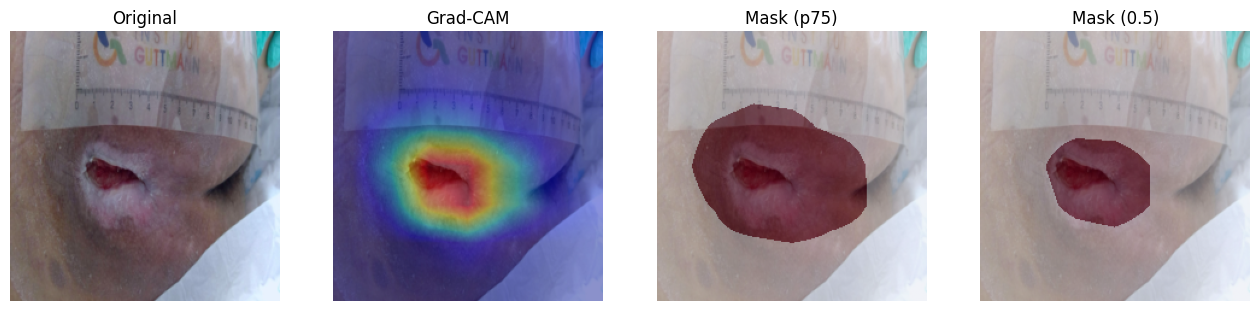


Prediction Results:
Predicted Stage: 3
Probabilities:
Stage 1: 0.15
Stage 2: 0.32
Stage 3: 0.36
Stage 4: 0.08
Stage 5: 0.09


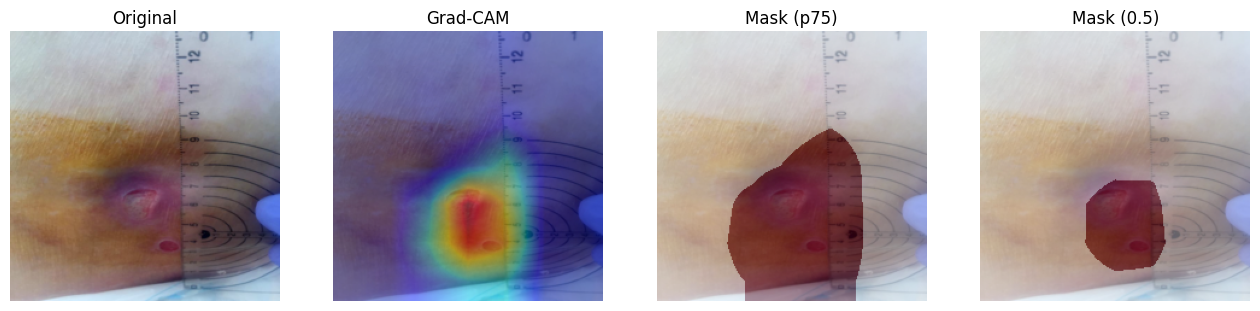


Prediction Results:
Predicted Stage: 4
Probabilities:
Stage 1: 0.00
Stage 2: 0.01
Stage 3: 0.04
Stage 4: 0.94
Stage 5: 0.01


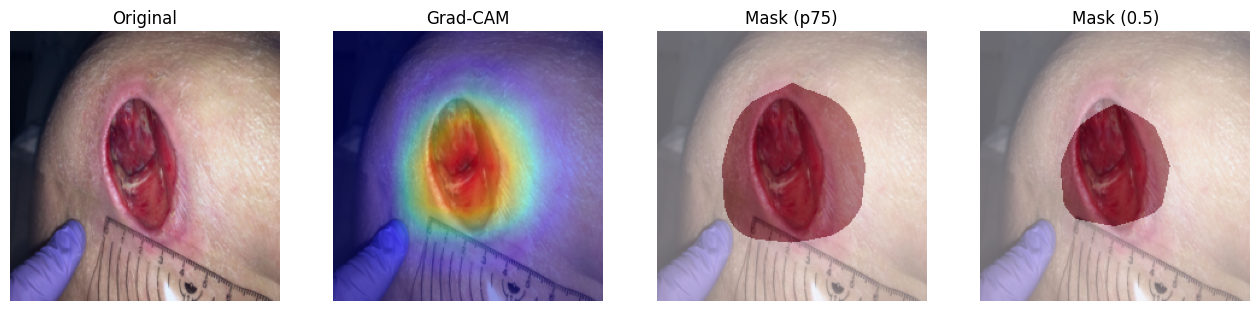

In [21]:
image_paths = [
    "../demo_images/case1.jpg",
    "../demo_images/case2.jpg",
    "../demo_images/case3.jpg"
]

for path in image_paths:
    evaluate_image(path)

Example cases interpretation: The first example corresponds to a borderline case between Stage 3 and Stage 4, where the model assigns similar probabilities to both classes, reflecting the inherent ambiguity also observed in clinical practice. The second example represents a borderline case between Stage 2 and Stage 3, again showing a more distributed probability output and highlighting the difficulty of classification based solely on visual information. In contrast, the third example is a clear and well-defined Stage 4 ulcer, where the model provides a highly confident prediction, correctly identifying the lesion and focusing its attention on the most relevant region.